<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [29]:
df = pd.read_csv('/Users/michalbando/Downloads/Różne/IT/Python/data/survey_data.csv')

#Display the top 10 records
df['Industry'].value_counts()

Industry
Software Development                          11918
Other:                                         3077
Fintech                                        1641
Internet, Telecomm or Information Services     1629
Banking/Financial Services                     1371
Healthcare                                     1277
Manufacturing                                  1265
Retail and Consumer Services                   1264
Government                                      962
Media & Advertising Services                    894
Higher Education                                890
Transportation, or Supply Chain                 859
Computer Systems Design and Services            844
Energy                                          578
Insurance                                       389
Name: count, dtype: int64

<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


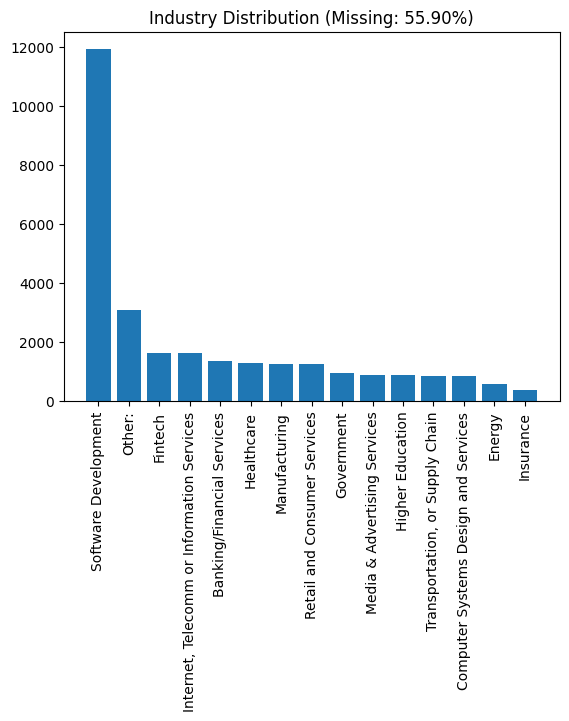

In [30]:
plt.bar(df['Industry'].value_counts().index, df['Industry'].value_counts().values)
missing_pct = df['Industry'].isnull().mean() * 100
plt.xticks(rotation=90)
plt.title(f'Industry Distribution (Missing: {missing_pct:.2f}%)')
plt.show()

## Notable trends
- Most respondents are from the 'Software Development' industry.
- Lowest representation is seen in 'Insurance' and 'Energy' industries.
- More than 50% of the data in the 'Industry' column is missing. 

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [31]:
mean_comp = df['ConvertedCompYearly'].mean()
std_comp = df['ConvertedCompYearly'].std()

threshold = mean_comp + (3 * std_comp)
outliers = df[df['ConvertedCompYearly'] > threshold]

print(f"Mean Compensation: {mean_comp:.2f}")
print(f"Standard Deviation: {std_comp:.2f}")
print(f"Outlier Threshold (Mean + 3*Std): {threshold:.2f}")
print(f"Number of outliers: {len(outliers)}")
print("\nOutliers in ConvertedCompYearly:")
display(outliers[['ConvertedCompYearly']].head())

Mean Compensation: 86155.29
Standard Deviation: 186756.97
Outlier Threshold (Mean + 3*Std): 646426.21
Number of outliers: 89

Outliers in ConvertedCompYearly:


,ConvertedCompYearly
529,650000.0
828,1000000.0
1932,945000.0
2171,750000.0
2187,2000000.0


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


Q1: 32712.00, Q3: 107971.50, IQR: 75259.50
Lower bound: -80177.25, Upper bound: 220860.75
Number of IQR outliers: 978 (1.49% of rows)


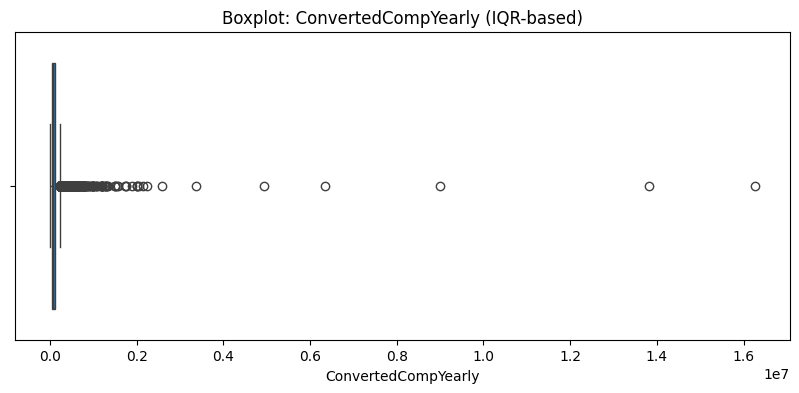

,ConvertedCompYearly
428,230000.0
456,300000.0
461,254425.0
529,650000.0
545,400000.0


In [32]:
# Convert to numeric first (non-numeric -> NaN)  # upewniamy się, że kolumna jest typu numerycznego
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')

# Obliczamy kwartyle i IQR  # Q1 = 25th percentile, Q3 = 75th percentile
comp = df['ConvertedCompYearly'].dropna()
Q1 = comp.quantile(0.25)  # pierwszy kwartyl (dolny)
Q3 = comp.quantile(0.75)  # trzeci kwartyl (górny)
IQR = Q3 - Q1  # rozstęp międzykwartylowy

# Ustalamy granice dla outlierów (1.5 * IQR)  # klasyczna definicja IQR-based fences
lower_bound = Q1 - 1.5 * IQR  # dolna granica
upper_bound = Q3 + 1.5 * IQR  # górna granica

# Filtrujemy wiersze będące outlierami (poniżej dolnej lub ponad górną granicą)
outliers_iqr = df[(df['ConvertedCompYearly'] < lower_bound) | (df['ConvertedCompYearly'] > upper_bound)]

# Informacje i szybkie podglądy  # wyświetlamy ile outlierów i przykłady
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")
print(f"Number of IQR outliers: {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.2f}% of rows)")

# Boxplot dla wizualnej weryfikacji  # pomocne, żeby zobaczyć rozkład i outliery
plt.figure(figsize=(10,4))
sns.boxplot(x=df['ConvertedCompYearly'])
plt.title('Boxplot: ConvertedCompYearly (IQR-based)')
plt.show()

# Pokaż pierwsze kilka outlierów  # jeśli chcesz zobaczyć dodatkowe kolumny, rozwiń listę
display(outliers_iqr[['ConvertedCompYearly']].head())

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [33]:
# Tworzymy nowy DataFrame bez outlierów wykrytych metodą IQR  # zachowujemy kopię, żeby nie tracić oryginału
mask = (df['ConvertedCompYearly'] >= lower_bound) & (df['ConvertedCompYearly'] <= upper_bound)
df_no_outliers = df[mask].copy()

# Informacje o rozmiarach  # pokażemy ile wierszy usunęliśmy
print(f"Original shape: {df.shape}")
print(f"Shape after removing IQR outliers: {df_no_outliers.shape}")
removed = df.shape[0] - df_no_outliers.shape[0]
print(f"Removed {removed} rows ({removed/df.shape[0]*100:.2f}%) as IQR outliers")

# Szybkie porównanie statystyk kompensacji przed i po  # sprawdzamy, jak zmieniły się miary
print('\nConvertedCompYearly - before:')
display(df['ConvertedCompYearly'].describe())
print('\nConvertedCompYearly - after removing outliers:')
display(df_no_outliers['ConvertedCompYearly'].describe())

Original shape: (65437, 114)
Shape after removing IQR outliers: (22457, 114)
Removed 42980 rows (65.68%) as IQR outliers

ConvertedCompYearly - before:


count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64


ConvertedCompYearly - after removing outliers:


count     22457.000000
mean      71347.201897
std       51271.396445
min           1.000000
25%       32000.000000
50%       63694.000000
75%      101281.000000
max      220207.000000
Name: ConvertedCompYearly, dtype: float64

<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


Numeric columns used for correlation: ['ResponseId', 'CompTotal', 'WorkExp', 'JobSatPoints_1', 'JobSatPoints_4', 'JobSatPoints_5', 'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9', 'JobSatPoints_10', 'JobSatPoints_11', 'ConvertedCompYearly', 'JobSat', 'Age_numeric']


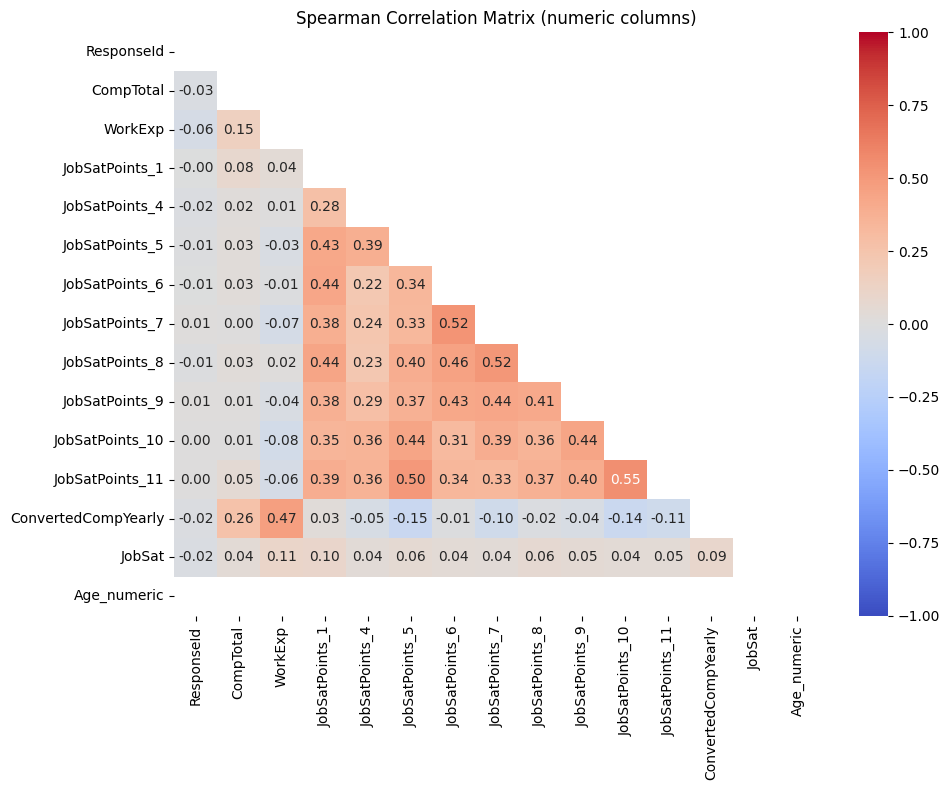


Correlations with Age_numeric:


ResponseId            NaN
CompTotal             NaN
WorkExp               NaN
JobSatPoints_1        NaN
JobSatPoints_4        NaN
JobSatPoints_5        NaN
JobSatPoints_6        NaN
JobSatPoints_7        NaN
JobSatPoints_8        NaN
JobSatPoints_9        NaN
JobSatPoints_10       NaN
JobSatPoints_11       NaN
ConvertedCompYearly   NaN
JobSat                NaN
Age_numeric           NaN
Name: Age_numeric, dtype: float64

In [34]:
# Krok 1: Mapowanie kolumny 'Age' na wartości numeryczne (przybliżone)  # najpierw spróbujemy konwersji bezpośredniej
age_numeric = pd.to_numeric(df_no_outliers['Age'], errors='coerce')  # jeśli są liczby zapisane jako tekst, zostaną skonwertowane

# Słownik mapujący typowe przedziały wiekowe na przybliżone wartości (midpoint)
age_map = {
    'Under 18': 17,
    '18 - 24 years': 21,
    '18-24': 21,
    '25 - 34 years': 29,
    '25-34': 29,
    '35 - 44 years': 39,
    '45 - 54 years': 49,
    '55 - 64 years': 59,
    '65 or older': 70
}

# Jeśli konwersja się nie powiodła (NaN), zastosujemy mapowanie tekstowe
age_mapped = df_no_outliers['Age'].map(age_map)

# Końcowa kolumna numeryczna: używamy wartości skonwertowanej jeśli dostępna, inaczej wartości z mapowania
df_no_outliers['Age_numeric'] = age_numeric.fillna(age_mapped)

# Krok 2: Wybór kolumn numerycznych i obliczenie macierzy korelacji  # używamy Spearmana (bardziej odporny na nieliniowości/rangi)
numeric_cols = df_no_outliers.select_dtypes(include=['number']).columns.tolist()
print('Numeric columns used for correlation:', numeric_cols)

corr = df_no_outliers[numeric_cols].corr(method='spearman')  # macierz korelacji Spearmana

# Krok 3: Wizualizacja macierzy korelacji  # heatmap z annotacją ułatwia interpretację
plt.figure(figsize=(10,8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # maska, żeby pokazać tylko dolną trójkątną macierzy
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Spearman Correlation Matrix (numeric columns)')
plt.tight_layout()
plt.show()

# Na koniec pokażemy kilka statystyk pomocniczych  # np. korelacje z Age_numeric posortowane malejąco
if 'Age_numeric' in corr.columns:
    print('\nCorrelations with Age_numeric:')
    display(corr['Age_numeric'].sort_values(ascending=False))
else:
    print('\nAge_numeric not present in numeric columns - sprawdź zawartość kolumny Age')

<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
